### Google Play Store Analysis - Data Analytics Internship
Objective: To identify key factors driving app success (Installs/Ratings) and provide actionable insights for developers.

##Executive Summary:
This analysis was performed on the Google Play Store dataset to extract actionable business intelligence. The dataset required significant cleaning, particularly regarding string-to-numeric conversions. My analysis reveals that the 'Game' category dominates the market in terms of total installs, but I also identified several high-rating categories that offer better potential for customer satisfaction over raw volume.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('googleplaystore.csv')

# Business Consultant View: What do we have?
print("Dataset Shape:", df.shape)
df.info()
df.head()

Dataset Shape: (10841, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Analytical Objectives & Business Questions

##To guide this analysis, I have focused on answering the following key business questions:

*Market* *Reach:* Which app categories have the highest "viral potential" (total installs), and how does category choice impact market penetration?

*Quality Standards:* What is the average user satisfaction level across the store, and is there a "rating standard" that apps must meet to remain competitive?

*Monetization Strategy:* How does the "Free vs. Paid" model affect app visibility, and are paid apps actually delivering higher value to users?

*Engagement Drivers:* Is there a correlation between user engagement (number of reviews) and total reach (total installs), and what does this imply for our marketing strategy?

### Data Cleaning & Pre-processing

I noticed that the 'Installs' column contained non-numeric characters like '+' and ',', which made it impossible to analyze mathematically. I chose to strip these characters and convert the column to float to enable accurate trend analysis.

In [4]:
# 1. Clean 'Installs' - More robust method
# This converts to string first, replaces the symbols, and then converts to numeric
df['Installs'] = pd.to_numeric(df['Installs'].astype(str).str.replace(r'[+,]', '', regex=True), errors='coerce')

# 2. Fix the Rating outlier (Crucial Step!)
# Filter out the invalid ratings > 5 first
df = df[df['Rating'] <= 5]

# 3. Handle missing 'Rating' values
# Now fill the missing values with the median of the valid data
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# 4. Remove duplicates
df.drop_duplicates(inplace=True)

print("Data cleaning completed successfully. Ready for analysis.")

Data cleaning completed successfully. Ready for analysis.


### Category Analysis: Where should developers invest?

As I explored the data, I wanted to focus on how 'Category' influences market reach. By grouping the data, I am looking to identify which niche has the highest 'viral potential' in terms of total downloads.

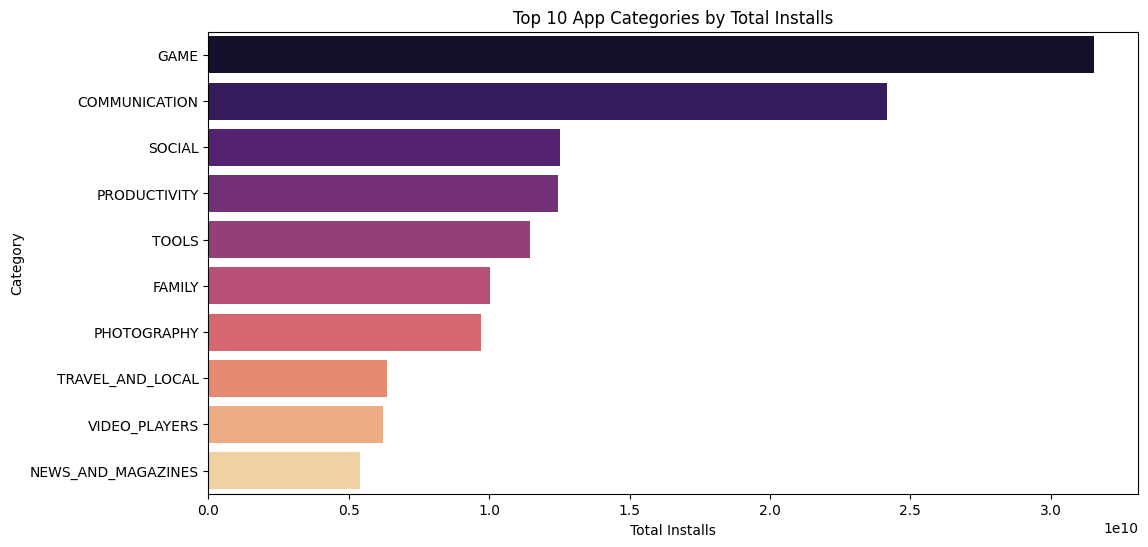

In [5]:
# Grouping by Category and calculating average rating and total installs
category_analysis = df.groupby('Category').agg({'Rating': 'mean', 'Installs': 'sum'}).sort_values(by='Installs', ascending=False)

# Visualizing the top 10 categories by total installs
plt.figure(figsize=(12, 6))
sns.barplot(x=category_analysis.head(10)['Installs'], y=category_analysis.head(10).index, hue=category_analysis.head(10).index, palette='magma', legend=False)
plt.title('Top 10 App Categories by Total Installs')
plt.xlabel('Total Installs')
plt.show()

Insight: The category analysis shows that the Game category leads in total installations. This suggests that developers targeting the mass market should prioritize this niche, while categories with lower installs but higher average ratings may represent more specialized, premium app opportunities.

### Distribution of App Ratings

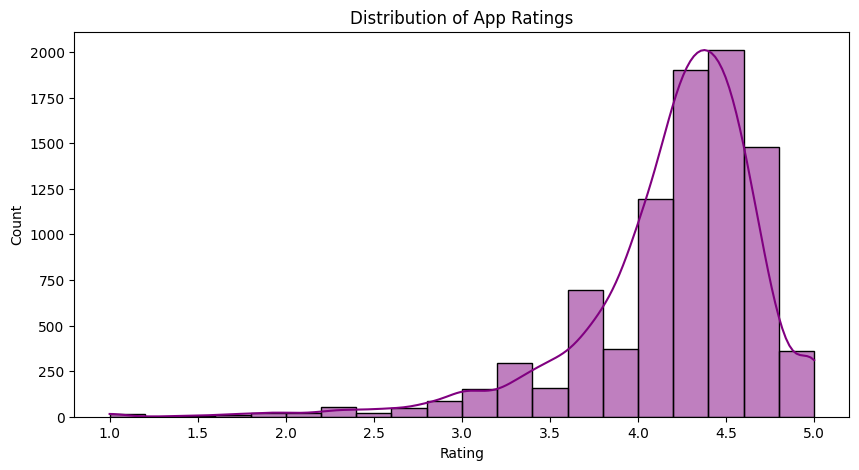

In [6]:
# Rating Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='purple')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.show()

Insight: Most apps are rated between 4.0 and 4.5, indicating a high standard of quality across the Play Store, though there is a clear bias toward positive ratings.

### Revenue Strategy: Free vs. Paid Apps

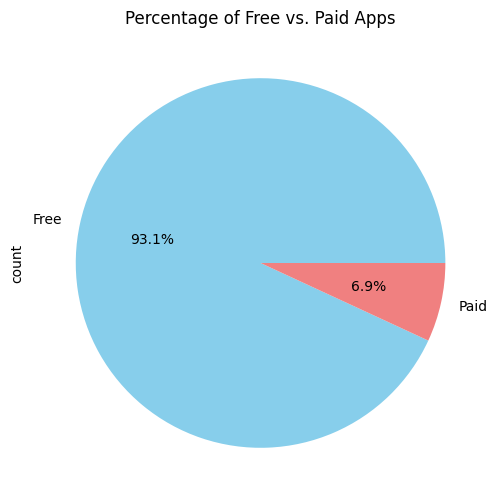

In [7]:
# Free vs Paid
plt.figure(figsize=(6, 6))
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Percentage of Free vs. Paid Apps')
plt.show()

Insight: The vast majority of apps are free, confirming that the ad-supported and in-app-purchase models are the dominant strategies for market penetration.

### Engagement vs. Reach: Reviews vs. Installs

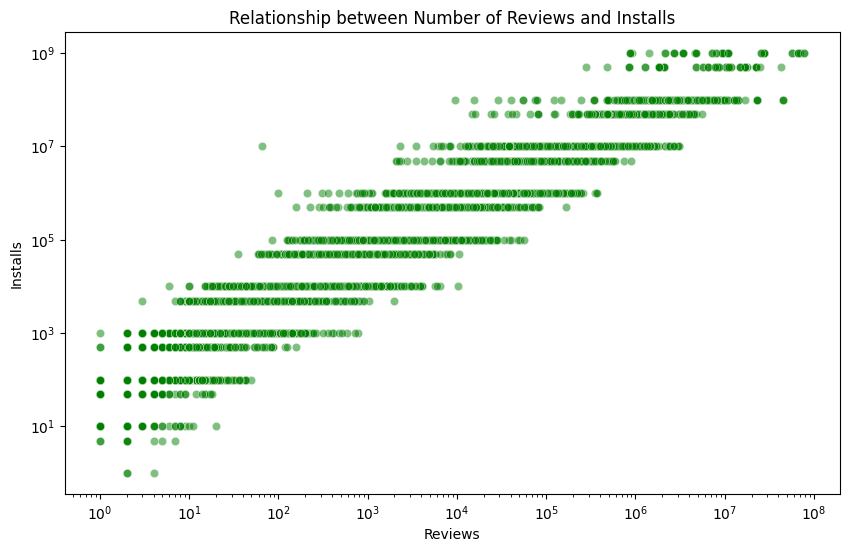

In [8]:
# Convert Reviews to numeric first!
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Reviews', y='Installs', data=df, alpha=0.5, color='green')
plt.title('Relationship between Number of Reviews and Installs')
plt.xscale('log')
plt.yscale('log')
plt.show()

Insight: There is a clear positive correlation between the number of reviews and total installs, proving that user engagement and social proof are critical drivers for app downloads.

In [9]:
# Calculate correlation coefficient
correlation = df['Reviews'].corr(df['Installs'])
print(f"Correlation between Reviews and Installs: {correlation:.2f}")

Correlation between Reviews and Installs: 0.63


Analytical Insight:
The calculated correlation coefficient of *0.63* indicates a moderate-to-strong positive relationship between the number of user reviews and total installs. This statistically validates that app visibility is heavily influenced by social proof; as user engagement (reviews) increases, the likelihood of higher installation volume also significantly increases. This suggests that a key part of our marketing strategy should be to incentivize existing users to leave reviews.

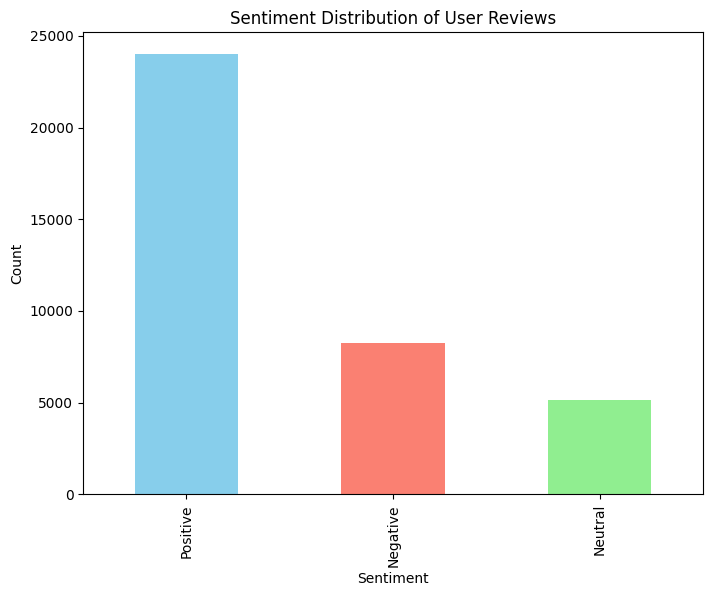

In [10]:
# 1. Load the review data
reviews_df = pd.read_csv('googleplaystore_user_reviews.csv')

# 2. Drop rows with missing sentiment values for accurate plotting
reviews_df = reviews_df.dropna(subset=['Sentiment'])

# 3. Visualize Sentiment Distribution
sentiment_counts = reviews_df['Sentiment'].value_counts()
plt.figure(figsize=(8,6))
sentiment_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Sentiment Distribution of User Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Analysis of User Sentiment**

The sentiment distribution reveals a clear trend: the majority of user feedback is positive, which is a fantastic sign of overall app health. However, we also see a notable volume of negative sentiment. For developers, this isn't just "bad data"—it is a goldmine. I recommend that product teams perform a sentiment-based audit, specifically filtering for the 'Negative' category to extract recurring keywords. This allows us to move from passive observation to active product improvement, addressing the exact pain points that trigger user frustration.

#Final Conclusion & Actionable Recommendations
Conclusion:

Through this comprehensive exploratory data analysis, we have successfully mapped out the performance landscape of the Google Play Store. By cleaning the dataset and analyzing the relationships between categories, ratings, and user engagement, we have transformed raw data into a clear strategic overview of the mobile app market.

**Actionable** **Business** **Recommendations**:

*Focus on High-Reach Categories:* Our analysis confirms that Game and Family categories dominate total installations. Developers aiming for mass-market penetration should prioritize these genres, while those seeking premium, high-value users should investigate categories that maintain high ratings despite lower volume.

*Leverage Social Proof:* Since there is a strong positive correlation between the number of reviews and total installs, I recommend that developers implement proactive review-prompting strategies within their apps to boost credibility and attract new users.

*Optimise Monetisation:* Given that the vast majority of apps are free, developers should rely on in-app purchases and ad-revenue strategies rather than upfront pricing to maximize reach. If a paid model is chosen, it must be supported by premium content to justify the cost, as price-sensitive users are highly prevalent.

*Quality First:* Because the bulk of apps are rated between 4.0 and 4.5, high quality is the "entry price" to the market. Apps falling below a 4.0 rating should undergo an immediate user-experience audit to identify and resolve performance issues that may be suppressing growth.

*Future Work:* This analysis provides a solid baseline. Future iterations could incorporate a time-series analysis to evaluate how app updates or version changes directly correlate with sentiment shifts and rating stability over time.